# Crops and livestock products using FAOSTAT Data

In [1]:
import pandas as pd
import requests
import os

print("FAOSTAT project started")

FAOSTAT project started


In [2]:
import faostat

print("FAOSTAT imported successfully")

FAOSTAT imported successfully


In [2]:
import requests
import os

token = os.getenv("FAOSTAT_TOKEN")

headers = {
    "Authorization": f"Bearer {token}"
}

url = "https://faostatservices.fao.org/api/v1/en/groups"

response = requests.get(url, headers=headers)

print("Status:", response.status_code)
print(response.text[:500])

Status: 200
{"metadata": {"processing_time": 10,"datasource": "PRODUCTION","output_type": "OBJECTS"},"data": [{"code":"Q","label":"Production"},{"code":"D","label":"Food Security and Nutrition"},{"code":"FB","label":"Food Balances"},{"code":"T","label":"Trade"},{"code":"P","label":"Prices"},{"code":"CAD","label":"Cost and Affordability of a Healthy Diet"},{"code":"FAD","label":"Food and Diet"},{"code":"R","label":"Land, Inputs and Sustainability"},{"code":"O","label":"Population and Employment"},{"code":"I"


In [3]:
import requests
import os
import pandas as pd

token = os.getenv("FAOSTAT_TOKEN")

headers = {
    "Authorization": f"Bearer {token}"
}

url = "https://faostatservices.fao.org/api/v1/en/groups"

response = requests.get(url, headers=headers)

data = response.json()["data"]

groups = pd.DataFrame(data)

groups

,code,label
0,Q,Production
1,D,Food Security and Nutrition
2,FB,Food Balances
3,T,Trade
4,P,Prices
5,CAD,Cost and Affordability of a Healthy Diet
6,FAD,Food and Diet
7,R,"Land, Inputs and Sustainability"
8,O,Population and Employment
9,I,Investment


In [4]:
import requests
import os
import pandas as pd

token = os.getenv("FAOSTAT_TOKEN")

headers = {
    "Authorization": f"Bearer {token}"
}

url = "https://faostatservices.fao.org/api/v1/en/domains/Q/"

response = requests.get(url, headers=headers)

print("Status:", response.status_code)

q_data = response.json()["data"]

q_domains = pd.DataFrame(q_data)

q_domains

Status: 200


,code,label,date_update,note_update,release_current,state_current,year_current,release_next,state_next,year_next
0,QCL,Crops and livestock products,2025-12-31,,2025-12-31,final,2024,2026-12,final,2025
1,QI,Production Indices,2026-05-11,,2026-05-11,final,2024,2027-02,final,2025
2,QV,Value of Agricultural Production,2026-05-11,,2026-05-11,final,2024,2027-02,final,2025


In [5]:
import requests
import os
import pandas as pd

token = os.getenv("FAOSTAT_TOKEN")

headers = {
    "Authorization": f"Bearer {token}"
}

url = "https://faostatservices.fao.org/api/v1/en/dimensions/QCL/"

response = requests.get(url, headers=headers)

print("Status:", response.status_code)
print(response.text[:2000])

Status: 200
{"metadata": {"processing_time": 11,"datasource": "PRODUCTION","output_type": "OBJECTS"},"data": [{"id":"area","href":"/codes/area/","subdimensions":[{"id":"countries","label":"Countries","href":"/codes/countries/","coding_systems":["M49","FAO","ISO2","ISO3"]},{"id":"regions","label":"Regions","href":"/codes/regions/","coding_systems":["M49","FAO","ISO2","ISO3"]},{"id":"specialgroups","label":"Special Groups","href":"/codes/specialgroups/","coding_systems":["M49","FAO","ISO2","ISO3"]}]},{"id":"element","href":"/codes/element/","subdimensions":[{"id":"elements","label":"Elements","href":"/codes/elements/","coding_systems":[]}]},{"id":"item","href":"/codes/item/","subdimensions":[{"id":"items","label":"Items","href":"/codes/items/","coding_systems":["CPC","FAO"]},{"id":"itemsagg","label":"Items Aggregated","href":"/codes/itemsagg/","coding_systems":["CPC","FAO"]}]},{"id":"year","href":"/codes/year/","subdimensions":[{"id":"years","label":"Years","href":"/codes/years/","coding

In [6]:
url = "https://faostatservices.fao.org/api/v1/en/codes/element/QCL"

response = requests.get(url, headers=headers)

print("Status:", response.status_code)
print(response.text[:3000])

Status: 200
{"metadata": {"processing_time": 15,"datasource": "PRODUCTION","output_type": "OBJECTS"},"data": [{"code":"2312","label":"Area harvested","aggregate_type":"0"},{"code":"2413","label":"Yield","aggregate_type":"0"},{"code":"2510","label":"Production Quantity","aggregate_type":"0"},{"code":"2111","label":"Stocks","aggregate_type":"0"},{"code":"2313","label":"Producing Animals/Slaughtered","aggregate_type":"0"}]}


In [7]:
url = "https://faostatservices.fao.org/api/v1/en/codes/item/QCL"

response = requests.get(url, headers=headers)

print("Status:", response.status_code)
print(response.text[:3000])

Status: 200
{"metadata": {"processing_time": 35,"datasource": "PRODUCTION","output_type": "OBJECTS"},"data": [{"code":"809","label":"Abaca, manila hemp, raw","parent":"QC\u003e","aggregate_type":"0"},{"code":"800","label":"Agave fibres, raw, n.e.c.","parent":"QC\u003e","aggregate_type":"0"},{"code":"221","label":"Almonds, in shell","parent":"QC\u003e","aggregate_type":"0"},{"code":"711","label":"Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw","parent":"QC\u003e","aggregate_type":"0"},{"code":"515","label":"Apples","parent":"QC\u003e","aggregate_type":"0"},{"code":"526","label":"Apricots","parent":"QC\u003e","aggregate_type":"0"},{"code":"226","label":"Areca nuts","parent":"QC\u003e","aggregate_type":"0"},{"code":"366","label":"Artichokes","parent":"QC\u003e","aggregate_type":"0"},{"code":"367","label":"Asparagus","parent":"QC\u003e","aggregate_type":"0"},{"code":"1107","label":"Asses","parent":"QA\u003e","aggregate_type":"0"},{"code":"572","label":"Avocados",

In [8]:
items = response.json()["data"]

items_df = pd.DataFrame(items)

crops = items_df[
    items_df["label"].str.contains(
        "Wheat|Rice|Maize|Sugar cane|Cotton|Potatoes",
        case=False,
        na=False
    )
]

crops[["code", "label", "parent"]]

,code,label,parent
23,89,Buckwheat,QC>
64,767,"Cotton lint, ginned",QD>
65,329,Cotton seed,QD>
66,331,Cottonseed oil,QD>
98,446,Green corn (maize),QC>
125,56,Maize (corn),QC>
157,60,Oil of maize,QD>
203,116,Potatoes,QC>
224,27,Rice,QC>
228,328,"Seed cotton, unginned",QC>


In [9]:
url = "https://faostatservices.fao.org/api/v1/en/codes/area/QCL"

response = requests.get(url, headers=headers)

print("Status:", response.status_code)

Status: 200


In [10]:
areas = response.json()["data"]

areas_df = pd.DataFrame(areas)

pakistan = areas_df[
    areas_df["label"].str.contains("Pakistan", case=False, na=False)
]

pakistan

,code,label,aggregate_type
141,165,Pakistan,0


In [12]:
url = "https://faostatservices.fao.org/api/v1/en/data/QCL"

response = requests.get(
    url,
    headers=headers,
    params={"area_code__1": "165"}
)

print("Status:", response.status_code)
print(response.text[:2000])

Status: 500
Please add at least one filter.


In [13]:
url = "https://faostatservices.fao.org/api/v1/en/data/QCL"

params = {
    "area": "165",
    "item": "15",
    "element": "2413",
    "year": "2024"
}

response = requests.get(
    url,
    headers=headers,
    params=params
)

print("Status:", response.status_code)
print(response.url)
print(response.text[:3000])

Status: 200
https://faostatservices.fao.org/api/v1/en/data/QCL?area=165&item=15&element=2413&year=2024
{"metadata": {"processing_time": 76,"datasource": "PRODUCTION","dsd": [{"label": "Domain Code","type": "code","key": "Domain Code","data_type": "string"},{"label": "Domain","type": "label","key": "Domain","data_type": "string"},{"label": "Area Code","type": "code","key": "Area Code","dimension_id": "area","data_type": "string"},{"label": "Area","type": "label","key": "Area","dimension_id": "area","data_type": "string"},{"label": "Element Code","type": "code","key": "Element Code","dimension_id": "element","data_type": "string"},{"label": "Element","type": "label","key": "Element","dimension_id": "element","data_type": "string"},{"label": "Item Code","type": "code","key": "Item Code","dimension_id": "item","data_type": "string"},{"label": "Item","type": "label","key": "Item","dimension_id": "item","data_type": "string"},{"label": "Year Code","type": "code","key": "Year Code","dimension

In [17]:
url = "https://faostatservices.fao.org/api/v1/en/data/QCL"

params = {
    "area": "165",
    "item": "15",
    "element": "2413",
    "year": "2024"
}

response = requests.get(
    url,
    headers=headers,
    params=params
)

result = response.json()

print("Status:", response.status_code)
print("Rows:", len(result.get("data", [])))
print(result.get("data", []))

Status: 200
Rows: 1
[{'Domain Code': 'QCL', 'Domain': 'Crops and livestock products', 'Area Code': '165', 'Area': 'Pakistan', 'Element Code': '5412', 'Element': 'Yield', 'Item Code': '15', 'Item': 'Wheat', 'Year Code': '2024', 'Year': '2024', 'Unit': 'kg/ha', 'Value': '3268.3', 'Flag': 'A', 'Flag Description': 'Official value', 'Note': ''}]


In [18]:
import time
import pandas as pd
import requests

url = "https://faostatservices.fao.org/api/v1/en/data/QCL"

years = range(2000, 2025)

all_data = []

for year in years:

    params = {
        "area": "165",
        "item": "15",
        "element": "2413",
        "year": str(year)
    }

    response = requests.get(
        url,
        headers=headers,
        params=params
    )

    if response.status_code == 200:
        rows = response.json().get("data", [])
        all_data.extend(rows)
        print(year, "→", len(rows), "rows")
    else:
        print(year, "→ ERROR", response.status_code)

    time.sleep(0.2)

wheat_yield = pd.DataFrame(all_data)

print("\nTotal rows:", len(wheat_yield))

2000 → 1 rows
2001 → 1 rows
2002 → 1 rows
2003 → 1 rows
2004 → 1 rows
2005 → 1 rows
2006 → 1 rows
2007 → 1 rows
2008 → 1 rows
2009 → 1 rows
2010 → 1 rows
2011 → 1 rows
2012 → 1 rows
2013 → 1 rows
2014 → 1 rows
2015 → 1 rows
2016 → 1 rows
2017 → 1 rows
2018 → 1 rows
2019 → 1 rows
2020 → 1 rows
2021 → 1 rows
2022 → 1 rows
2023 → 1 rows
2024 → 1 rows

Total rows: 25


In [19]:
crops = {
    "Wheat": 15,
    "Rice": 27,
    "Maize": 56,
    "Sugar cane": 156,
    "Potatoes": 116,
    "Cotton": 328
}

In [20]:
elements = {
    "Area harvested": 2312,
    "Yield": 2413,
    "Production Quantity": 2510
}

In [21]:
import time
import pandas as pd
import requests

url = "https://faostatservices.fao.org/api/v1/en/data/QCL"

crops = {
    "Wheat": 15,
    "Rice": 27,
    "Maize": 56,
    "Sugar cane": 156,
    "Potatoes": 116,
    "Cotton": 328
}

all_data = []

for crop, item_code in crops.items():

    for year in range(2000, 2025):

        params = {
            "area": "165",
            "item": str(item_code),
            "element": "2413",
            "year": str(year)
        }

        response = requests.get(
            url,
            headers=headers,
            params=params
        )

        if response.status_code == 200:

            rows = response.json().get("data", [])

            for row in rows:
                row["Crop"] = crop

            all_data.extend(rows)

            print(crop, year, "→", len(rows))

        else:
            print(crop, year, "→ ERROR", response.status_code)

        time.sleep(0.2)

yield_df = pd.DataFrame(all_data)

print("\nTotal rows:", len(yield_df))

Wheat 2000 → 1
Wheat 2001 → 1
Wheat 2002 → 1
Wheat 2003 → 1
Wheat 2004 → 1
Wheat 2005 → 1
Wheat 2006 → 1
Wheat 2007 → 1
Wheat 2008 → 1
Wheat 2009 → 1
Wheat 2010 → 1
Wheat 2011 → 1
Wheat 2012 → 1
Wheat 2013 → 1
Wheat 2014 → 1
Wheat 2015 → 1
Wheat 2016 → 1
Wheat 2017 → 1
Wheat 2018 → 1
Wheat 2019 → 1
Wheat 2020 → 1
Wheat 2021 → 1
Wheat 2022 → 1
Wheat 2023 → 1
Wheat 2024 → 1
Rice 2000 → 1
Rice 2001 → 1
Rice 2002 → 1
Rice 2003 → 1
Rice 2004 → 1
Rice 2005 → 1
Rice 2006 → 1
Rice 2007 → 1
Rice 2008 → 1
Rice 2009 → 1
Rice 2010 → 1
Rice 2011 → 1
Rice 2012 → 1
Rice 2013 → 1
Rice 2014 → 1
Rice 2015 → 1
Rice 2016 → 1
Rice 2017 → 1
Rice 2018 → 1
Rice 2019 → 1
Rice 2020 → 1
Rice 2021 → 1
Rice 2022 → 1
Rice 2023 → 1
Rice 2024 → 1
Maize 2000 → 1
Maize 2001 → 1
Maize 2002 → 1
Maize 2003 → 1
Maize 2004 → 1
Maize 2005 → 1
Maize 2006 → 1
Maize 2007 → 1
Maize 2008 → 1
Maize 2009 → 1
Maize 2010 → 1
Maize 2011 → 1
Maize 2012 → 1
Maize 2013 → 1
Maize 2014 → 1
Maize 2015 → 1
Maize 2016 → 1
Maize 2017 → 1
Maize

In [22]:
elements = {
    "Area Harvested": 2312,
    "Production Quantity": 2510
}

feature_data = []

for feature, element_code in elements.items():

    for crop, item_code in crops.items():

        for year in range(2000, 2025):

            params = {
                "area": "165",
                "item": str(item_code),
                "element": str(element_code),
                "year": str(year)
            }

            response = requests.get(
                url,
                headers=headers,
                params=params
            )

            if response.status_code == 200:
                rows = response.json().get("data", [])

                for row in rows:
                    row["Crop"] = crop
                    row["Feature"] = feature

                feature_data.extend(rows)

            else:
                print(
                    feature,
                    crop,
                    year,
                    "→ ERROR",
                    response.status_code
                )

            time.sleep(0.2)

feature_df = pd.DataFrame(feature_data)

print("Total rows:", len(feature_df))

Total rows: 300


In [23]:
yield_df[["Crop", "Year", "Unit", "Value"]].head()

,Crop,Year,Unit,Value
0,Wheat,2000,kg/ha,2490.7
1,Wheat,2001,kg/ha,2325.4
2,Wheat,2002,kg/ha,2262.1
3,Wheat,2003,kg/ha,2387.8
4,Wheat,2004,kg/ha,2373.3


In [24]:
feature_df[["Crop", "Year", "Feature", "Unit", "Value"]].head(10)

,Crop,Year,Feature,Unit,Value
0,Wheat,2000,Area Harvested,ha,8463000
1,Wheat,2001,Area Harvested,ha,8180800
2,Wheat,2002,Area Harvested,ha,8057500
3,Wheat,2003,Area Harvested,ha,8033900
4,Wheat,2004,Area Harvested,ha,8216200
5,Wheat,2005,Area Harvested,ha,8358000
6,Wheat,2006,Area Harvested,ha,8447900
7,Wheat,2007,Area Harvested,ha,8578000
8,Wheat,2008,Area Harvested,ha,8549800
9,Wheat,2009,Area Harvested,ha,9046000


In [25]:
print(feature_df["Feature"].value_counts())

Feature
Area Harvested         150
Production Quantity    150
Name: count, dtype: int64


# Units check

In [26]:
feature_df.groupby(["Feature", "Unit"]).size()

Feature              Unit
Area Harvested       ha      150
Production Quantity  t       150
dtype: int64

# Missing values

In [27]:
print("Yield missing:", yield_df["Value"].isna().sum())
print("Features missing:", feature_df["Value"].isna().sum())

Yield missing: 0
Features missing: 0


# Duplicate check

In [28]:
print(
    "Yield duplicates:",
    yield_df.duplicated(["Crop", "Year"]).sum()
)

print(
    "Feature duplicates:",
    feature_df.duplicated(
        ["Crop", "Year", "Feature"]
    ).sum()
)

Yield duplicates: 0
Feature duplicates: 0


# clean the Yield 

In [29]:
yield_clean = yield_df[
    ["Crop", "Year", "Value"]
].copy()

yield_clean = yield_clean.rename(
    columns={"Value": "Yield_kg_ha"}
)

yield_clean["Year"] = pd.to_numeric(
    yield_clean["Year"]
)

yield_clean["Yield_kg_ha"] = pd.to_numeric(
    yield_clean["Yield_kg_ha"]
)

# separate Area and Production 

In [30]:
area_df = feature_df[
    feature_df["Feature"] == "Area Harvested"
][["Crop", "Year", "Value"]].copy()

area_df = area_df.rename(
    columns={"Value": "Area_Harvested_ha"}
)

area_df["Area_Harvested_ha"] = pd.to_numeric(
    area_df["Area_Harvested_ha"]
)

In [31]:
production_df = feature_df[
    feature_df["Feature"] == "Production Quantity"
][["Crop", "Year", "Value"]].copy()

production_df = production_df.rename(
    columns={"Value": "Production_tonnes"}
)

production_df["Production_tonnes"] = pd.to_numeric(
    production_df["Production_tonnes"]
)

# Mergeing 

In [33]:
area_df["Year"] = pd.to_numeric(area_df["Year"])
production_df["Year"] = pd.to_numeric(production_df["Year"])

In [34]:
final_df = (
    yield_clean
    .merge(
        area_df,
        on=["Crop", "Year"],
        how="inner"
    )
    .merge(
        production_df,
        on=["Crop", "Year"],
        how="inner"
    )
)

In [35]:
print("Shape:", final_df.shape)

final_df.head(10)

Shape: (150, 5)


,Crop,Year,Yield_kg_ha,Area_Harvested_ha,Production_tonnes
0,Wheat,2000,2490.7,8463000,21078600.0
1,Wheat,2001,2325.4,8180800,19023700.0
2,Wheat,2002,2262.1,8057500,18226500.0
3,Wheat,2003,2387.8,8033900,19183300.0
4,Wheat,2004,2373.3,8216200,19499800.0
5,Wheat,2005,2585.8,8358000,21612300.0
6,Wheat,2006,2518.6,8447900,21276900.0
7,Wheat,2007,2715.6,8578000,23294600.0
8,Wheat,2008,2451.4,8549800,20958800.0
9,Wheat,2009,2656.8,9046000,24033000.0


In [36]:
final_df.to_csv(
    "faostat_pakistan_crop_data.csv",
    index=False
)

print("Dataset saved successfully!")
print("Shape:", final_df.shape)

Dataset saved successfully!
Shape: (150, 5)


# Basic  overview of Dataset

In [37]:
print("Dataset Shape:", final_df.shape)

print("\nData Types:")
print(final_df.dtypes)

print("\nMissing Values:")
print(final_df.isnull().sum())

print("\nDuplicate Rows:")
print(final_df.duplicated().sum())

print("\nBasic Statistics:")
display(final_df.describe())

Dataset Shape: (150, 5)

Data Types:
Crop                     str
Year                   int64
Yield_kg_ha          float64
Area_Harvested_ha      int64
Production_tonnes    float64
dtype: object

Missing Values:
Crop                 0
Year                 0
Yield_kg_ha          0
Area_Harvested_ha    0
Production_tonnes    0
dtype: int64

Duplicate Rows:
0

Basic Statistics:


,Year,Yield_kg_ha,Area_Harvested_ha,Production_tonnes
count,150.00000,150.000000,1.500000e+02,1.500000e+02
mean,2012.00000,14954.710000,2.789766e+06,1.856596e+07
std,7.23526,20256.111265,2.852221e+06,2.218790e+07
min,2000.00000,1124.100000,1.014530e+05,1.568000e+06
25%,2006.00000,2603.550000,1.002225e+06,4.650942e+06
50%,2012.00000,3677.800000,1.828184e+06,8.230725e+06
75%,2018.00000,21158.925000,2.972829e+06,2.416677e+07
max,2024.00000,74251.600000,9.734249e+06,8.865059e+07


# summary Crop-wise 

In [38]:
crop_summary = final_df.groupby("Crop").agg(
    Years=("Year", "count"),
    Avg_Yield=("Yield_kg_ha", "mean"),
    Min_Yield=("Yield_kg_ha", "min"),
    Max_Yield=("Yield_kg_ha", "max"),
    Avg_Area=("Area_Harvested_ha", "mean"),
    Avg_Production=("Production_tonnes", "mean")
).round(2)

display(crop_summary)

,Years,Avg_Yield,Min_Yield,Max_Yield,Avg_Area,Avg_Production
Crop,,,,,,
Cotton,25,1966.03,1124.1,2330.3,2715821.92,5371813.44
Maize,25,4065.96,1708.6,6388.6,1192242.84,5157887.84
Potatoes,25,20590.65,13344.7,25266.6,174083.48,3757571.20
Rice,25,3489.32,2754.2,4066.2,2791132.36,9856773.78
Sugar cane,25,56904.74,45385.4,74251.6,1102742.16,63408113.76
Wheat,25,2711.57,2262.1,3268.3,8762573.36,23843581.24


# Actual EDA visualization

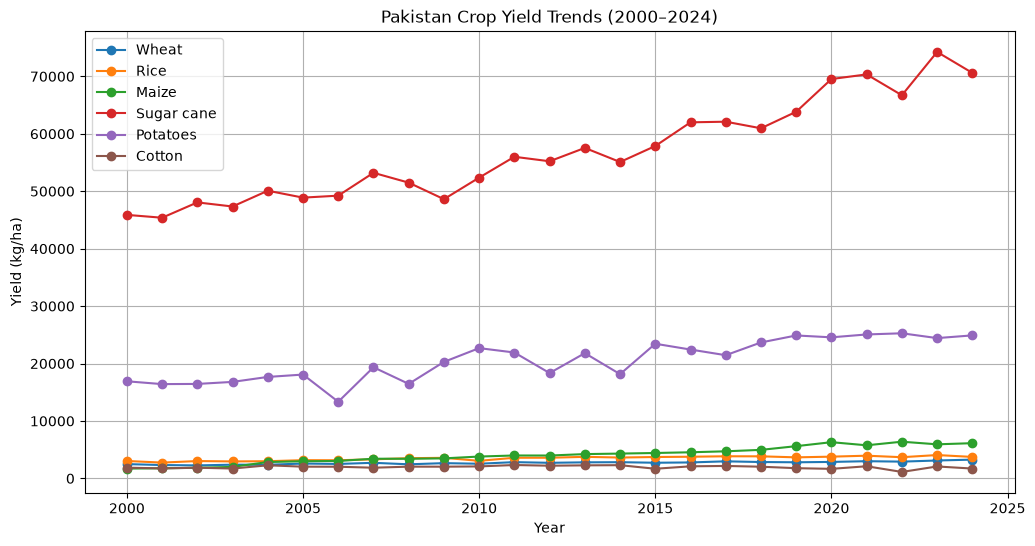

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for crop in final_df["Crop"].unique():
    data = final_df[final_df["Crop"] == crop]

    plt.plot(
        data["Year"],
        data["Yield_kg_ha"],
        marker="o",
        label=crop
    )

plt.title("Pakistan Crop Yield Trends (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Yield (kg/ha)")
plt.legend()
plt.grid(True)
plt.show()

# Area vs Production

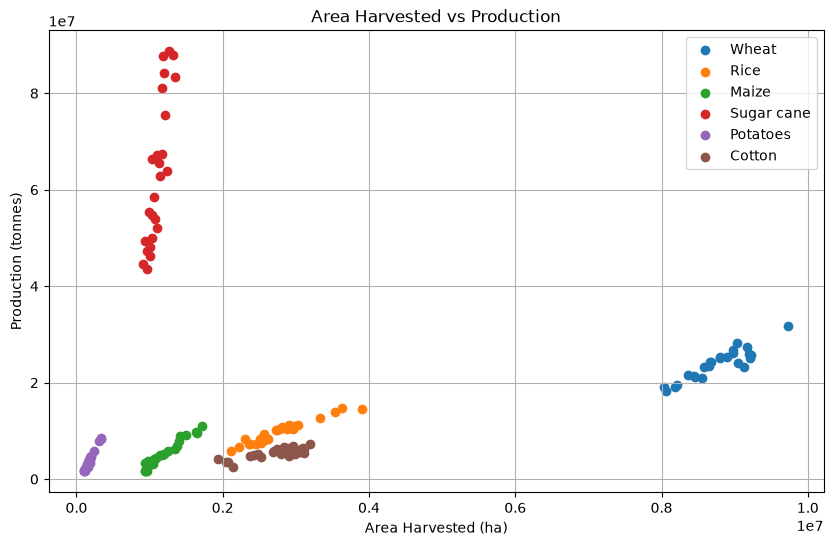

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for crop in final_df["Crop"].unique():
    data = final_df[final_df["Crop"] == crop]
    
    plt.scatter(
        data["Area_Harvested_ha"],
        data["Production_tonnes"],
        label=crop
    )

plt.title("Area Harvested vs Production")
plt.xlabel("Area Harvested (ha)")
plt.ylabel("Production (tonnes)")
plt.legend()
plt.grid(True)
plt.show()

# Checking Numerical Relationship 

In [44]:
final_df[
    ["Yield_kg_ha", "Area_Harvested_ha", "Production_tonnes"]
].corr().round(3)

,Yield_kg_ha,Area_Harvested_ha,Production_tonnes
Yield_kg_ha,1.000,-0.403,0.851
Area_Harvested_ha,-0.403,1.000,0.058
Production_tonnes,0.851,0.058,1.000


# Time-based feature engineering

In [45]:
final_df = final_df.sort_values(
    ["Crop", "Year"]
).reset_index(drop=True)

final_df.head()

,Crop,Year,Yield_kg_ha,Area_Harvested_ha,Production_tonnes
0,Cotton,2000,1870.6,2927500,5476167.0
1,Cotton,2001,1738.1,3115800,5415600.0
2,Cotton,2002,1865.1,2793600,5210400.0
3,Cotton,2003,1715.2,2989300,5127300.0
4,Cotton,2004,2280.1,3192600,7279400.0


In [46]:
final_df["Previous_Yield"] = (
    final_df.groupby("Crop")["Yield_kg_ha"].shift(1)
)

final_df["Previous_Area"] = (
    final_df.groupby("Crop")["Area_Harvested_ha"].shift(1)
)

final_df["Previous_Production"] = (
    final_df.groupby("Crop")["Production_tonnes"].shift(1)
)

final_df.head(10)

,Crop,Year,Yield_kg_ha,Area_Harvested_ha,Production_tonnes,Previous_Yield,Previous_Area,Previous_Production
0,Cotton,2000,1870.6,2927500,5476167.0,NaN,NaN,NaN
1,Cotton,2001,1738.1,3115800,5415600.0,1870.6,2927500.0,5476167.0
2,Cotton,2002,1865.1,2793600,5210400.0,1738.1,3115800.0,5415600.0
3,Cotton,2003,1715.2,2989300,5127300.0,1865.1,2793600.0,5210400.0
4,Cotton,2004,2280.1,3192600,7279400.0,1715.2,2989300.0,5127300.0
5,Cotton,2005,2042.4,3103000,6337475.0,2280.1,3192600.0,7279400.0
6,Cotton,2006,2033.3,3074900,6252200.0,2042.4,3103000.0,6337475.0
7,Cotton,2007,1858.7,3054300,5676900.0,2033.3,3074900.0,6252200.0
8,Cotton,2008,2046.2,2819900,5770000.0,1858.7,3054300.0,5676900.0
9,Cotton,2009,2039.5,3105700,6334200.0,2046.2,2819900.0,5770000.0


In [47]:
ml_df = final_df.dropna(
    subset=[
        "Previous_Yield",
        "Previous_Area",
        "Previous_Production"
    ]
).copy()

print("Original shape:", final_df.shape)
print("ML dataset shape:", ml_df.shape)

Original shape: (150, 8)
ML dataset shape: (144, 8)


# years verification

In [48]:
print(
    ml_df["Year"].min(),
    "→",
    ml_df["Year"].max()
)

print(sorted(ml_df["Year"].unique()))

2001 → 2024
[np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


# Train/Test split

In [49]:
train_df = ml_df[ml_df["Year"] <= 2019].copy()
test_df = ml_df[ml_df["Year"] >= 2020].copy()

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nTraining years:")
print(train_df["Year"].min(), "→", train_df["Year"].max())

print("\nTesting years:")
print(test_df["Year"].min(), "→", test_df["Year"].max())

Training shape: (114, 8)
Testing shape: (30, 8)

Training years:
2001 → 2019

Testing years:
2020 → 2024


# X_train, X_test, y_train, y_test

In [50]:
features = [
    "Crop",
    "Year",
    "Previous_Yield",
    "Previous_Area",
    "Previous_Production"
]

target = "Yield_kg_ha"

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (114, 5)
y_train: (114,)
X_test: (30, 5)
y_test: (30,)


# Crop Encode

In [53]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_crop = encoder.fit_transform(X_train[["Crop"]])
X_test_crop = encoder.transform(X_test[["Crop"]])

print("Encoded train shape:", X_train_crop.shape)
print("Encoded test shape:", X_test_crop.shape)

Encoded train shape: (114, 6)
Encoded test shape: (30, 6)


# Numerical features

In [54]:
numeric_features = [
    "Year",
    "Previous_Yield",
    "Previous_Area",
    "Previous_Production"
]

X_train_numeric = X_train[numeric_features].values
X_test_numeric = X_test[numeric_features].values

print("Numeric train:", X_train_numeric.shape)
print("Numeric test:", X_test_numeric.shape)

Numeric train: (114, 4)
Numeric test: (30, 4)


# Combine Catogrical and Numerical Feature

In [56]:
import numpy as np
X_train_final = np.hstack([
    X_train_numeric,
    X_train_crop
])

X_test_final = np.hstack([
    X_test_numeric,
    X_test_crop
])

print("Final X_train:", X_train_final.shape)
print("Final X_test:", X_test_final.shape)

Final X_train: (114, 10)
Final X_test: (30, 10)


# Step 1 — Random Forest train 

In [57]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


# Predictions

In [58]:
y_pred = rf_model.predict(X_test_final)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[1949.155  1969.8615 2013.771  1979.9985 2042.4505 5317.86   5317.86
 5317.86   5316.9235 5317.86  ]


# Evaluation

In [59]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

MAE : 1764.18
RMSE: 3419.42
R²  : 0.9806


# Actual vs Predicted 

In [60]:
results = test_df[["Crop", "Year"]].copy()

results["Actual_Yield"] = y_test.values
results["Predicted_Yield"] = y_pred

results["Error"] = (
    results["Actual_Yield"] -
    results["Predicted_Yield"]
)

results.head(10)

,Crop,Year,Actual_Yield,Predicted_Yield,Error
20,Cotton,2020,1661.6,1949.1550,-287.5550
21,Cotton,2021,2114.7,1969.8615,144.8385
22,Cotton,2022,1124.1,2013.7710,-889.6710
23,Cotton,2023,2078.2,1979.9985,98.2015
24,Cotton,2024,1713.3,2042.4505,-329.1505
45,Maize,2020,6305.4,5317.8600,987.5400
46,Maize,2021,5763.7,5317.8600,445.8400
47,Maize,2022,6388.6,5317.8600,1070.7400
48,Maize,2023,5933.5,5316.9235,616.5765
49,Maize,2024,6133.3,5317.8600,815.4400


# Feature Importance

In [61]:
feature_names = (
    numeric_features +
    list(encoder.get_feature_names_out(["Crop"]))
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

importance_df

,Feature,Importance
1,Previous_Yield,0.484500
3,Previous_Production,0.282821
8,Crop_Sugar cane,0.152807
2,Previous_Area,0.043300
6,Crop_Potatoes,0.025482
0,Year,0.011070
4,Crop_Cotton,0.000014
5,Crop_Maize,0.000003
9,Crop_Wheat,0.000002
7,Crop_Rice,0.000001


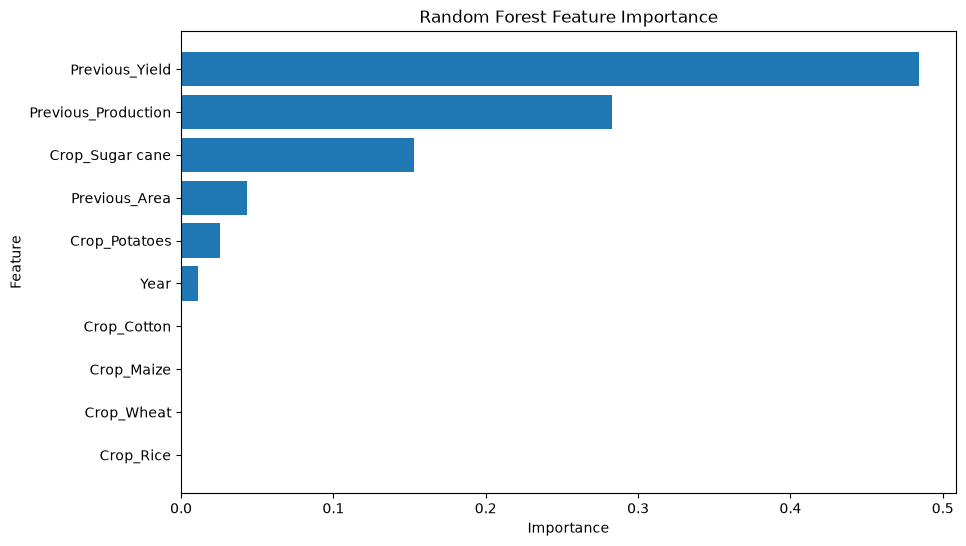

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

# Crop-wise Evaluation

In [63]:
crop_results = results.copy()

crop_performance = (
    crop_results
    .groupby("Crop")
    .apply(
        lambda x: pd.Series({
            "MAE": mean_absolute_error(
                x["Actual_Yield"],
                x["Predicted_Yield"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    x["Actual_Yield"],
                    x["Predicted_Yield"]
                )
            ),
            "R2": r2_score(
                x["Actual_Yield"],
                x["Predicted_Yield"]
            )
        }),
        include_groups=False
    )
    .round(2)
)

crop_performance

,MAE,RMSE,R2
Crop,,,
Cotton,349.88,450.15,-0.58
Maize,787.23,820.44,-11.59
Potatoes,1109.06,1165.44,-13.07
Rice,326.88,379.70,-6.29
Sugar cane,7860.73,8230.57,-10.61
Wheat,151.31,184.27,-0.63


# Model improving

In [64]:
final_df = final_df.sort_values(
    ["Crop", "Year"]
).reset_index(drop=True)

final_df["Yield_Lag_2"] = (
    final_df.groupby("Crop")["Yield_kg_ha"].shift(2)
)

final_df["Yield_Lag_3"] = (
    final_df.groupby("Crop")["Yield_kg_ha"].shift(3)
)

final_df["Yield_Rolling_3"] = (
    final_df.groupby("Crop")["Yield_kg_ha"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

final_df.head(10)

,Crop,Year,Yield_kg_ha,Area_Harvested_ha,Production_tonnes,Previous_Yield,Previous_Area,Previous_Production,Yield_Lag_2,Yield_Lag_3,Yield_Rolling_3
0,Cotton,2000,1870.6,2927500,5476167.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Cotton,2001,1738.1,3115800,5415600.0,1870.6,2927500.0,5476167.0,NaN,NaN,NaN
2,Cotton,2002,1865.1,2793600,5210400.0,1738.1,3115800.0,5415600.0,1870.6,NaN,NaN
3,Cotton,2003,1715.2,2989300,5127300.0,1865.1,2793600.0,5210400.0,1738.1,1870.6,1824.600000
4,Cotton,2004,2280.1,3192600,7279400.0,1715.2,2989300.0,5127300.0,1865.1,1738.1,1772.800000
5,Cotton,2005,2042.4,3103000,6337475.0,2280.1,3192600.0,7279400.0,1715.2,1865.1,1953.466667
6,Cotton,2006,2033.3,3074900,6252200.0,2042.4,3103000.0,6337475.0,2280.1,1715.2,2012.566667
7,Cotton,2007,1858.7,3054300,5676900.0,2033.3,3074900.0,6252200.0,2042.4,2280.1,2118.600000
8,Cotton,2008,2046.2,2819900,5770000.0,1858.7,3054300.0,5676900.0,2033.3,2042.4,1978.133333
9,Cotton,2009,2039.5,3105700,6334200.0,2046.2,2819900.0,5770000.0,1858.7,2033.3,1979.400000


In [ ]:
# 1. Create lag features

df_lag = final_df.copy()

df_lag = df_lag.sort_values(["Crop", "Year"]).reset_index(drop=True)

# Previous 2 years' yield
df_lag["Yield_Lag_2"] = (
    df_lag.groupby("Crop")["Yield_kg_ha"].shift(2)
)

# Previous 3 years' yield
df_lag["Yield_Lag_3"] = (
    df_lag.groupby("Crop")["Yield_kg_ha"].shift(3)
)

# Rolling average of previous 3 years
df_lag["Yield_Rolling_3"] = (
    df_lag.groupby("Crop")["Yield_kg_ha"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

df_lag.head(10)

,Crop,Year,Yield_kg_ha,Area_Harvested_ha,Production_tonnes,Previous_Yield,Previous_Area,Previous_Production,Yield_Lag_2,Yield_Lag_3,Yield_Rolling_3
0,Cotton,2000,1870.6,2927500,5476167.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Cotton,2001,1738.1,3115800,5415600.0,1870.6,2927500.0,5476167.0,NaN,NaN,NaN
2,Cotton,2002,1865.1,2793600,5210400.0,1738.1,3115800.0,5415600.0,1870.6,NaN,NaN
3,Cotton,2003,1715.2,2989300,5127300.0,1865.1,2793600.0,5210400.0,1738.1,1870.6,1824.600000
4,Cotton,2004,2280.1,3192600,7279400.0,1715.2,2989300.0,5127300.0,1865.1,1738.1,1772.800000
5,Cotton,2005,2042.4,3103000,6337475.0,2280.1,3192600.0,7279400.0,1715.2,1865.1,1953.466667
6,Cotton,2006,2033.3,3074900,6252200.0,2042.4,3103000.0,6337475.0,2280.1,1715.2,2012.566667
7,Cotton,2007,1858.7,3054300,5676900.0,2033.3,3074900.0,6252200.0,2042.4,2280.1,2118.600000
8,Cotton,2008,2046.2,2819900,5770000.0,1858.7,3054300.0,5676900.0,2033.3,2042.4,1978.133333
9,Cotton,2009,2039.5,3105700,6334200.0,2046.2,2819900.0,5770000.0,1858.7,2033.3,1979.400000


In [66]:
print(df_lag.isnull().sum())

Crop                    0
Year                    0
Yield_kg_ha             0
Area_Harvested_ha       0
Production_tonnes       0
Previous_Yield          6
Previous_Area           6
Previous_Production     6
Yield_Lag_2            12
Yield_Lag_3            18
Yield_Rolling_3        18
dtype: int64


In [68]:
print(df_lag.columns)
print(df_lag.shape)

Index(['Crop', 'Year', 'Yield_kg_ha', 'Area_Harvested_ha', 'Production_tonnes',
       'Previous_Yield', 'Previous_Area', 'Previous_Production', 'Yield_Lag_2',
       'Yield_Lag_3', 'Yield_Rolling_3'],
      dtype='str')
(150, 11)


In [69]:
# Remove rows with missing lag/rolling features
ml_df_lag = df_lag.dropna().reset_index(drop=True)

print("ML dataset after lag features:")
print("Shape:", ml_df_lag.shape)

print("\nMissing values:")
print(ml_df_lag.isnull().sum())

ML dataset after lag features:
Shape: (132, 11)

Missing values:
Crop                   0
Year                   0
Yield_kg_ha            0
Area_Harvested_ha      0
Production_tonnes      0
Previous_Yield         0
Previous_Area          0
Previous_Production    0
Yield_Lag_2            0
Yield_Lag_3            0
Yield_Rolling_3        0
dtype: int64


# Separate Featureand Target for Machine Learning

In [70]:
# Target = current Yield
y = ml_df_lag["Yield_kg_ha"]

# Features
X = ml_df_lag[
    [
        "Crop",
        "Year",
        "Area_Harvested_ha",
        "Production_tonnes",
        "Previous_Yield",
        "Previous_Area",
        "Previous_Production",
        "Yield_Lag_2",
        "Yield_Lag_3",
        "Yield_Rolling_3"
    ]
]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (132, 10)
y shape: (132,)

Features:
['Crop', 'Year', 'Area_Harvested_ha', 'Production_tonnes', 'Previous_Yield', 'Previous_Area', 'Previous_Production', 'Yield_Lag_2', 'Yield_Lag_3', 'Yield_Rolling_3']

Target:
Yield_kg_ha


# Time-based train/test split

In [71]:
# Time-based train/test split

train_mask = ml_df_lag["Year"] <= 2019
test_mask = ml_df_lag["Year"] >= 2020

X_train = X[train_mask].copy()
X_test = X[test_mask].copy()

y_train = y[train_mask].copy()
y_test = y[test_mask].copy()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining years:")
print(X_train["Year"].min(), "→", X_train["Year"].max())

print("\nTesting years:")
print(X_test["Year"].min(), "→", X_test["Year"].max())

Training shape: (102, 10)
Testing shape: (30, 10)

Training years:
2003 → 2019

Testing years:
2020 → 2024


# One-Hot Encoding + numerical features combine.


In [72]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# -----------------------------
# Encode Crop
# -----------------------------
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_crop = encoder.fit_transform(
    X_train[["Crop"]]
)

X_test_crop = encoder.transform(
    X_test[["Crop"]]
)

print("Encoded train shape:", X_train_crop.shape)
print("Encoded test shape:", X_test_crop.shape)


# -----------------------------
# Numerical features
# -----------------------------
numeric_features = [
    "Year",
    "Area_Harvested_ha",
    "Production_tonnes",
    "Previous_Yield",
    "Previous_Area",
    "Previous_Production",
    "Yield_Lag_2",
    "Yield_Lag_3",
    "Yield_Rolling_3"
]

X_train_numeric = X_train[numeric_features].values
X_test_numeric = X_test[numeric_features].values

print("\nNumeric train:", X_train_numeric.shape)
print("Numeric test:", X_test_numeric.shape)


# -----------------------------
# Combine features
# -----------------------------
X_train_final = np.hstack([
    X_train_numeric,
    X_train_crop
])

X_test_final = np.hstack([
    X_test_numeric,
    X_test_crop
])

print("\nFinal X_train:", X_train_final.shape)
print("Final X_test:", X_test_final.shape)

Encoded train shape: (102, 6)
Encoded test shape: (30, 6)

Numeric train: (102, 9)
Numeric test: (30, 9)

Final X_train: (102, 15)
Final X_test: (30, 15)


In [73]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1
)

# Train
rf_model.fit(X_train_final, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = rf_model.predict(X_test_final)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-" * 30)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Evaluation
------------------------------
MAE  : 1810.29
RMSE : 3453.74
R²   : 0.9802


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Predictions
y_pred = rf_model.predict(X_test_final)

# Overall evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-" * 30)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Evaluation
------------------------------
MAE  : 1810.29
RMSE : 3453.74
R²   : 0.9802


# feature importance + crop-wise performance

In [77]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_final, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [78]:
feature_names = (
    numeric_features +
    list(encoder.get_feature_names_out(["Crop"]))
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df)

                Feature    Importance
5   Previous_Production  1.844432e-01
2     Production_tonnes  1.801810e-01
3        Previous_Yield  1.289914e-01
6           Yield_Lag_2  1.172756e-01
8       Yield_Rolling_3  1.137593e-01
7           Yield_Lag_3  1.114208e-01
13      Crop_Sugar cane  9.316589e-02
1     Area_Harvested_ha  2.368918e-02
4         Previous_Area  2.199834e-02
11        Crop_Potatoes  2.127934e-02
0                  Year  3.740093e-03
9           Crop_Cotton  5.243837e-05
14           Crop_Wheat  1.840073e-06
10           Crop_Maize  1.260788e-06
12            Crop_Rice  3.085701e-07


# Predictions + comparison

In [79]:
# Predictions
y_pred = rf_model.predict(X_test_final)

# Comparison dataframe
results_df = X_test.copy()

results_df["Actual_Yield"] = y_test.values
results_df["Predicted_Yield"] = y_pred
results_df["Error"] = (
    results_df["Actual_Yield"] -
    results_df["Predicted_Yield"]
)

results_df[
    [
        "Crop",
        "Year",
        "Actual_Yield",
        "Predicted_Yield",
        "Error"
    ]
].sort_values(["Crop", "Year"])

,Crop,Year,Actual_Yield,Predicted_Yield,Error
17,Cotton,2020,1661.6,1954.472667,-292.872667
18,Cotton,2021,2114.7,1938.856000,175.844000
19,Cotton,2022,1124.1,1968.174000,-844.074000
20,Cotton,2023,2078.2,1968.277000,109.923000
21,Cotton,2024,1713.3,1955.693333,-242.393333
39,Maize,2020,6305.4,5326.885667,978.514333
40,Maize,2021,5763.7,5326.885667,436.814333
41,Maize,2022,6388.6,5326.885667,1061.714333
42,Maize,2023,5933.5,5326.885667,606.614333
43,Maize,2024,6133.3,5326.885667,806.414333


# Gradient Boosting model

In [80]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Gradient Boosting Model
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    random_state=42,
    loss="squared_error"
)

gb_model.fit(X_train_final, y_train)

# Predictions
gb_pred = gb_model.predict(X_test_final)

# Evaluation
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Evaluation")
print("-" * 30)
print(f"MAE  : {gb_mae:.2f}")
print(f"RMSE : {gb_rmse:.2f}")
print(f"R²   : {gb_r2:.4f}")

Gradient Boosting Evaluation
------------------------------
MAE  : 1400.72
RMSE : 3014.09
R²   : 0.9849


# which features Gradient Boosting is actually using most.

In [82]:
# Gradient Boosting Feature Importance

feature_names = [
    "Year",
    "Area_Harvested_ha",
    "Production_tonnes",
    "Previous_Yield",
    "Previous_Area",
    "Previous_Production",
    "Yield_Lag_2",
    "Yield_Lag_3",
    "Yield_Rolling_3",
    "Crop_Cotton",
    "Crop_Maize",
    "Crop_Potatoes",
    "Crop_Rice",
    "Crop_Sugar cane",
    "Crop_Wheat"
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df)

                Feature    Importance
6           Yield_Lag_2  2.024371e-01
13      Crop_Sugar cane  2.013459e-01
2     Production_tonnes  1.434542e-01
5   Previous_Production  1.379937e-01
8       Yield_Rolling_3  1.269538e-01
3        Previous_Yield  8.993635e-02
7           Yield_Lag_3  4.849133e-02
11        Crop_Potatoes  2.514491e-02
4         Previous_Area  1.142583e-02
1     Area_Harvested_ha  6.950188e-03
0                  Year  5.788603e-03
9           Crop_Cotton  6.692578e-05
10           Crop_Maize  1.115242e-05
14           Crop_Wheat  9.947205e-10
12            Crop_Rice  0.000000e+00


# Grid Search CV

In [83]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.02, 0.03, 0.05],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train_final, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}

Best CV MAE:
9165.34628470962


In [84]:
# Best Gradient Boosting Model
best_gb_model = grid_search.best_estimator_

# Test predictions
best_gb_pred = best_gb_model.predict(X_test_final)

# Evaluation
best_mae = mean_absolute_error(y_test, best_gb_pred)
best_rmse = np.sqrt(mean_squared_error(y_test, best_gb_pred))
best_r2 = r2_score(y_test, best_gb_pred)

print("Tuned Gradient Boosting Evaluation")
print("-" * 40)
print(f"MAE  : {best_mae:.2f}")
print(f"RMSE : {best_rmse:.2f}")
print(f"R²   : {best_r2:.4f}")

Tuned Gradient Boosting Evaluation
----------------------------------------
MAE  : 1610.75
RMSE : 3108.07
R²   : 0.9840


In [85]:
final_model = gb_model

print("Final model selected: Gradient Boosting")

Final model selected: Gradient Boosting


# 2025 Area Harvested + Production Quantity

In [92]:
TOKEN = "eyJraWQiOiJVSFE2dmwrekFTaGRpSGpsOFFSK0d2ZW13RWIzSjZNdytYNTRURXZtNUNJPSIsImFsZyI6IlJTMjU2In0.eyJzdWIiOiI2MmQ1MDQ0NC01MDExLTcwMWUtMzhkYS0wZWYzY2Q2Mjc3MjUiLCJpc3MiOiJodHRwczovL2NvZ25pdG8taWRwLmV1LXdlc3QtMS5hbWF6b25hd3MuY29tL2V1LXdlc3QtMV9iTkVMTk9DMnYiLCJ2ZXJzaW9uIjoyLCJjbGllbnRfaWQiOiIyY3NsdHNpZ2FvODVpdmhwNm9qcDFhaWM3byIsIm9yaWdpbl9qdGkiOiIwYmQxOWRjYy1jZmJjLTQxMTktOGNiMy0wMGE2ZTg1NzkyMjEiLCJldmVudF9pZCI6ImRkMzY2ZjQyLTM2NzAtNGMzNS1iZjE1LWM4MzI0MjI3M2QzOCIsInRva2VuX3VzZSI6ImFjY2VzcyIsInNjb3BlIjoiYXdzLmNvZ25pdG8uc2lnbmluLnVzZXIuYWRtaW4gcGhvbmUgb3BlbmlkIHByb2ZpbGUgZW1haWwiLCJhdXRoX3RpbWUiOjE3ODY3NjQ2MzIsImV4cCI6MTc4Njc5MTQxMCwiaWF0IjoxNzg2Nzg3ODEwLCJqdGkiOiI2MzI0M2U2My0wZmUzLTQyMzUtYjQxNS01OGFhZjUxMWFkYmEiLCJ1c2VybmFtZSI6Ik11aGFtbWFkLUhhc3NhbiJ9.DaSJdniSBNrP9NCUAlWr-YDNLKI3MecQYA2aOQMdrN6xz3tBkWHeNsF9izUuJKOZZk3PFLq0XE8TU1xKa-Qw3VmA3wGRodFETFqUkmHW9R0A2QMqje6GovXvfCBlSkdjbhwTpvm4zWvKO_BwtMdcdsGkIzPXSwSAgNoXXJ7PoSXrf6cAB_hx92u113Ksp1TMWMbVX6UwCTEEIlMVkzNmJQH1J_NvByN-T5wgZC1SAaz17-kgrOUqYWVvi9Rzuh3oZgyW9xA5db0d1ynFUooQqxMHuejexBG-pZFGzvktniXrxSdXirhd42eNiXuSlqyvQIBxma4AmAgpGwp1NDA1fg"

In [94]:
import requests

url = "https://faostatservices.fao.org/api/v1/en/data/QCL"

params = {
    "area": 165,
    "item": 15,
    "element": 5412,   # Yield
    "year": 2025
}

headers = {
    "Authorization": f"Bearer {TOKEN}"
}

response = requests.get(
    url,
    params=params,
    headers=headers,
    timeout=120
)

print("Status:", response.status_code)
print("URL:", response.url)
print("Response:", response.text[:1000])

Status: 200
URL: https://faostatservices.fao.org/api/v1/en/data/QCL?area=165&item=15&element=5412&year=2025
Response: {"metadata": {"processing_time": 71,"datasource": "PRODUCTION","dsd": [{"label": "Domain Code","type": "code","key": "Domain Code","data_type": "string"},{"label": "Domain","type": "label","key": "Domain","data_type": "string"},{"label": "Area Code","type": "code","key": "Area Code","dimension_id": "area","data_type": "string"},{"label": "Area","type": "label","key": "Area","dimension_id": "area","data_type": "string"},{"label": "Element Code","type": "code","key": "Element Code","dimension_id": "element","data_type": "string"},{"label": "Element","type": "label","key": "Element","dimension_id": "element","data_type": "string"},{"label": "Item Code","type": "code","key": "Item Code","dimension_id": "item","data_type": "string"},{"label": "Item","type": "label","key": "Item","dimension_id": "item","data_type": "string"},{"label": "Year Code","type": "code","key": "Year C

# 2025  6 crops  Area + Production data fetching

In [95]:
import requests
import pandas as pd

base_url = "https://faostatservices.fao.org/api/v1/en/data/QCL"

headers = {
    "Authorization": f"Bearer {TOKEN}"
}

crops = {
    "Wheat": 15,
    "Rice": 27,
    "Maize": 56,
    "Sugar cane": 156,
    "Potatoes": 116,
    "Cotton": 826
}

results = []

for crop, item_code in crops.items():

    # Area Harvested
    params_area = {
        "area": 165,
        "item": item_code,
        "element": 5312,
        "year": 2025
    }

    response_area = requests.get(
        base_url,
        params=params_area,
        headers=headers,
        timeout=120
    )

    data_area = response_area.json().get("data", [])

    # Production Quantity
    params_prod = {
        "area": 165,
        "item": item_code,
        "element": 5510,
        "year": 2025
    }

    response_prod = requests.get(
        base_url,
        params=params_prod,
        headers=headers,
        timeout=120
    )

    data_prod = response_prod.json().get("data", [])

    results.append({
        "Crop": crop,
        "Year": 2025,
        "Area_Harvested_ha": float(data_area[0]["Value"]) if data_area else None,
        "Production_tonnes": float(data_prod[0]["Value"]) if data_prod else None
    })

future_2025 = pd.DataFrame(results)

print(future_2025)

         Crop  Year Area_Harvested_ha Production_tonnes
0       Wheat  2025              None              None
1        Rice  2025              None              None
2       Maize  2025              None              None
3  Sugar cane  2025              None              None
4    Potatoes  2025              None              None
5      Cotton  2025              None              None


In [97]:
print("Status:", response.status_code)
print("URL:", response.url)
print("Response:")
print(response.text[:2000])

Status: 200
URL: https://faostatservices.fao.org/api/v1/en/data/QCL?area=165&item=15&year=2025
Response:
{"metadata": {"processing_time": 67,"datasource": "PRODUCTION","dsd": [{"label": "Domain Code","type": "code","key": "Domain Code","data_type": "string"},{"label": "Domain","type": "label","key": "Domain","data_type": "string"},{"label": "Area Code","type": "code","key": "Area Code","dimension_id": "area","data_type": "string"},{"label": "Area","type": "label","key": "Area","dimension_id": "area","data_type": "string"},{"label": "Element Code","type": "code","key": "Element Code","dimension_id": "element","data_type": "string"},{"label": "Element","type": "label","key": "Element","dimension_id": "element","data_type": "string"},{"label": "Item Code","type": "code","key": "Item Code","dimension_id": "item","data_type": "string"},{"label": "Item","type": "label","key": "Item","dimension_id": "item","data_type": "string"},{"label": "Year Code","type": "code","key": "Year Code","dimensi

In [106]:
TOKEN ="eyJraWQiOiJVSFE2dmwrekFTaGRpSGpsOFFSK0d2ZW13RWIzSjZNdytYNTRURXZtNUNJPSIsImFsZyI6IlJTMjU2In0.eyJzdWIiOiI2MmQ1MDQ0NC01MDExLTcwMWUtMzhkYS0wZWYzY2Q2Mjc3MjUiLCJpc3MiOiJodHRwczovL2NvZ25pdG8taWRwLmV1LXdlc3QtMS5hbWF6b25hd3MuY29tL2V1LXdlc3QtMV9iTkVMTk9DMnYiLCJ2ZXJzaW9uIjoyLCJjbGllbnRfaWQiOiIyY3NsdHNpZ2FvODVpdmhwNm9qcDFhaWM3byIsIm9yaWdpbl9qdGkiOiI1MWVmMmRjNC1lNjYwLTQ2M2YtOWI2My1lZTBmMjg0ZTNhODkiLCJ0b2tlbl91c2UiOiJhY2Nlc3MiLCJzY29wZSI6ImF3cy5jb2duaXRvLnNpZ25pbi51c2VyLmFkbWluIHBob25lIG9wZW5pZCBwcm9maWxlIGVtYWlsIiwiYXV0aF90aW1lIjoxNzg2ODE1MDM4LCJleHAiOjE3ODY4MTg2MzgsImlhdCI6MTc4NjgxNTAzOCwianRpIjoiNDM3NDkzMzYtNTYzMC00MDAyLTkxYmEtODdlZGQ0ZjhkZWVhIiwidXNlcm5hbWUiOiJNdWhhbW1hZC1IYXNzYW4ifQ.QE8R8yBh45VoS-6VUfy3UWG7r9iYh5cde41wPAGpWAXsDe-hq-nr4AFQT_tE1Wb78RDk1tbB1xggut2JIAmmt-L90yVHptaE3TQRyzCwkeRo__5CWamVLZc-neSnpt58Z3ZTN5rt56LM5KXCQTG1I2SmtwG_JnzjPKwXs2mItbl9h3i4eEWQN2yUlbtvUmSguK6l736hQyDz4o3JcXhdnxeg25CCqjfJEFv06GNiOes5YLwz_tHQ0XPBOCz-lWffcSfG4fJH6vD2DBuLDVTdGX7Vg2UF_3SCnJLJU-Nait6krpRD_3vq1hbG4aDU9gkYaD79Ul5KH5bUJe2URJlPlg"

In [108]:
import requests

url = "https://faostatservices.fao.org/api/v1/en/data/QCL"

headers = {
    "Authorization": f"Bearer {TOKEN}"
}

params = {
    "area": 165,
    "item": 15,
    "year": 2025
}

response = requests.get(
    url,
    params=params,
    headers=headers,
    timeout=120
)

print("Status:", response.status_code)
print("Response:", response.text[:500])

Status: 200
Response: {"metadata": {"processing_time": 82,"datasource": "PRODUCTION","dsd": [{"label": "Domain Code","type": "code","key": "Domain Code","data_type": "string"},{"label": "Domain","type": "label","key": "Domain","data_type": "string"},{"label": "Area Code","type": "code","key": "Area Code","dimension_id": "area","data_type": "string"},{"label": "Area","type": "label","key": "Area","dimension_id": "area","data_type": "string"},{"label": "Element Code","type": "code","key": "Element Code","dimension_id":


In [113]:
# Available DataFrames check karna

items = list(globals().items())

for name, obj in items:
    if hasattr(obj, "shape") and hasattr(obj, "columns"):
        print(name, "→", obj.shape)
        print("Columns:", list(obj.columns))
        print("-" * 60)

groups → (20, 2)
Columns: ['code', 'label']
------------------------------------------------------------
q_domains → (3, 10)
Columns: ['code', 'label', 'date_update', 'note_update', 'release_current', 'state_current', 'year_current', 'release_next', 'state_next', 'year_next']
------------------------------------------------------------
items_df → (338, 4)
Columns: ['code', 'label', 'parent', 'aggregate_type']
------------------------------------------------------------
areas_df → (278, 3)
Columns: ['code', 'label', 'aggregate_type']
------------------------------------------------------------
pakistan → (1, 3)
Columns: ['code', 'label', 'aggregate_type']
------------------------------------------------------------
wheat_yield → (25, 15)
Columns: ['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element', 'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']
------------------------------------------------------------
yield_df → (15

# Build the 2025 lag features

In [ ]:
# CREATE 2025 FORECAST FEATURES

# Use original historical dataset
historical = final_df.copy()

forecast_2025 = future_2025.copy()

forecast_2025["Previous_Yield"] = (
    historical[historical["Year"] == 2024]
    .set_index("Crop")["Yield_kg_ha"]
    .reindex(forecast_2025["Crop"])
    .values
)

forecast_2025["Previous_Area"] = (
    historical[historical["Year"] == 2024]
    .set_index("Crop")["Area_Harvested_ha"]
    .reindex(forecast_2025["Crop"])
    .values
)

forecast_2025["Previous_Production"] = (
    historical[historical["Year"] == 2024]
    .set_index("Crop")["Production_tonnes"]
    .reindex(forecast_2025["Crop"])
    .values
)

# 2-year lag = 2023
forecast_2025["Yield_Lag_2"] = (
    historical[historical["Year"] == 2023]
    .set_index("Crop")["Yield_kg_ha"]
    .reindex(forecast_2025["Crop"])
    .values
)

# 3-year lag = 2022
forecast_2025["Yield_Lag_3"] = (
    historical[historical["Year"] == 2022]
    .set_index("Crop")["Yield_kg_ha"]
    .reindex(forecast_2025["Crop"])
    .values
)

# Rolling 3-year yield = 2022, 2023, 2024 average
rolling_values = (
    historical[historical["Year"].isin([2022, 2023, 2024])]
    .groupby("Crop")["Yield_kg_ha"]
    .mean()
)

forecast_2025["Yield_Rolling_3"] = (
    rolling_values
    .reindex(forecast_2025["Crop"])
    .values
)

print("2025 Forecast Dataset:")
print("Shape:", forecast_2025.shape)

display(forecast_2025)

2025 Forecast Dataset:
Shape: (6, 10)


,Crop,Year,Area_Harvested_ha,Production_tonnes,Previous_Yield,Previous_Area,Previous_Production,Yield_Lag_2,Yield_Lag_3,Yield_Rolling_3
0,Wheat,2025,None,None,3268.3,9734249,31814444.0,3117.6,2919.6,3101.833333
1,Rice,2025,None,None,3740.6,3899215,14585231.0,4066.2,3690.3,3832.366667
2,Maize,2025,None,None,6133.3,1500000,9200000.0,5933.5,6388.6,6151.800000
3,Sugar cane,2025,None,None,70602.6,1193092,84235451.0,74251.6,66711.2,70521.800000
4,Potatoes,2025,None,None,24901.1,338715,8434370.0,24428.5,25266.6,24865.400000
5,Cotton,2025,None,None,1713.3,2043211,3500618.0,2078.2,1124.1,1638.533333


# 2025 Area Production Estimate 

In [115]:
# ESTIMATE 2025 AREA & PRODUCTION

historical = final_df.copy()

forecast_2025 = forecast_2025.copy()

for crop in forecast_2025["Crop"]:

    hist_crop = historical[
        (historical["Crop"] == crop) &
        (historical["Year"].isin([2022, 2023, 2024]))
    ].sort_values("Year")

    # Linear trend for Area
    area_model = np.polyfit(
        hist_crop["Year"],
        hist_crop["Area_Harvested_ha"],
        1
    )

    forecast_area = np.polyval(
        area_model,
        2025
    )

    # Linear trend for Production
    production_model = np.polyfit(
        hist_crop["Year"],
        hist_crop["Production_tonnes"],
        1
    )

    forecast_production = np.polyval(
        production_model,
        2025
    )

    forecast_2025.loc[
        forecast_2025["Crop"] == crop,
        "Area_Harvested_ha"
    ] = forecast_area

    forecast_2025.loc[
        forecast_2025["Crop"] == crop,
        "Production_tonnes"
    ] = forecast_production

print("2025 Forecast Features:")
display(forecast_2025)

2025 Forecast Features:


,Crop,Year,Area_Harvested_ha,Production_tonnes,Previous_Yield,Previous_Area,Previous_Production,Yield_Lag_2,Yield_Lag_3,Yield_Rolling_3
0,Wheat,2025,10005294.666667,34333653.0,3268.3,9734249,31814444.0,3117.6,2919.6,3101.833333
1,Rice,2025,4427125.333334,17054538.333335,3740.6,3899215,14585231.0,4066.2,3690.3,3832.366667
2,Maize,2025,1400883.666667,8190168.666666,6133.3,1500000,9200000.0,5933.5,6388.6,6151.800000
3,Sugar cane,2025,1104991.333333,82872400.999998,70602.6,1193092,84235451.0,74251.6,66711.2,70521.800000
4,Potatoes,2025,355728.666667,8727826.333333,24901.1,338715,8434370.0,24428.5,25266.6,24865.400000
5,Cotton,2025,2103107.333333,4740020.666667,1713.3,2043211,3500618.0,2078.2,1124.1,1638.533333


# 2025 Crop Encoding

In [116]:
# 2025 CROP ENCODING

crop_encoded_2025 = encoder.transform(
    forecast_2025[["Crop"]]
)

print("Encoded 2025 shape:", crop_encoded_2025.shape)

Encoded 2025 shape: (6, 6)


# Numeric features

In [117]:
# NUMERIC FEATURES

numeric_cols = [
    "Year",
    "Area_Harvested_ha",
    "Production_tonnes",
    "Previous_Yield",
    "Previous_Area",
    "Previous_Production",
    "Yield_Lag_2",
    "Yield_Lag_3",
    "Yield_Rolling_3"
]

X_2025_numeric = forecast_2025[numeric_cols].values

print("Numeric 2025 shape:", X_2025_numeric.shape)

Numeric 2025 shape: (6, 9)


# Final 15 features

In [118]:
# FINAL 2025 FEATURES

X_2025_final = np.hstack([
    X_2025_numeric,
    crop_encoded_2025
])

print("Final X_2025 shape:", X_2025_final.shape)

Final X_2025 shape: (6, 15)


In [119]:
# FINAL 2025 YIELD PREDICTION

predicted_yield_2025 = final_model.predict(X_2025_final)

forecast_results = forecast_2025[
    ["Crop", "Year"]
].copy()

forecast_results["Predicted_Yield_kg_ha"] = predicted_yield_2025

forecast_results["Predicted_Yield_kg_ha"] = (
    forecast_results["Predicted_Yield_kg_ha"].round(2)
)

print("2025 Predicted Crop Yield")
print("-" * 40)

display(forecast_results)

2025 Predicted Crop Yield
----------------------------------------


,Crop,Year,Predicted_Yield_kg_ha
0,Wheat,2025,3348.35
1,Rice,2025,3820.79
2,Maize,2025,5345.83
3,Sugar cane,2025,63499.67
4,Potatoes,2025,24931.90
5,Cotton,2025,2060.64


# 2025 Forecast Visualization

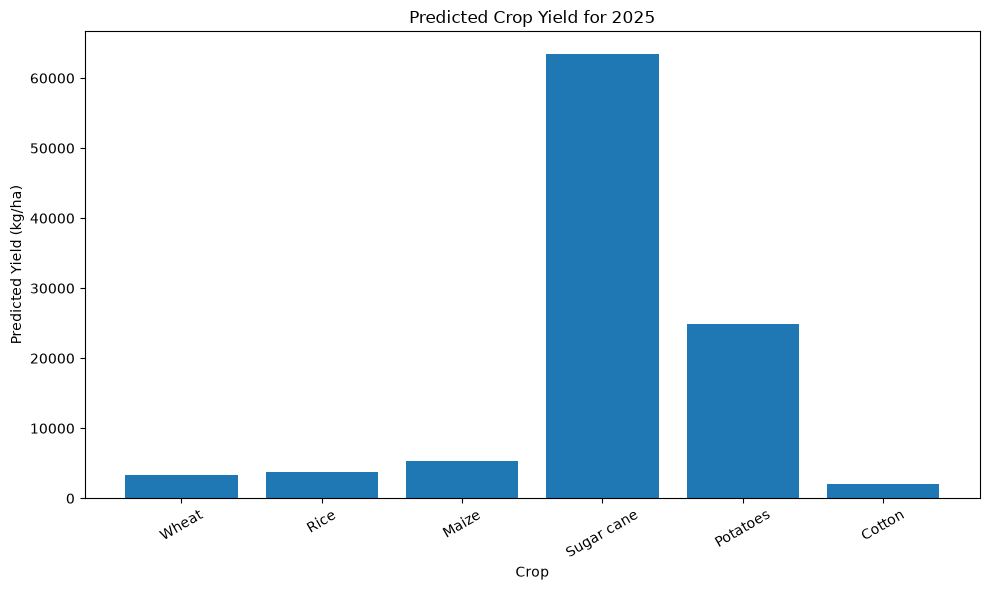

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    forecast_results["Crop"],
    forecast_results["Predicted_Yield_kg_ha"]
)

plt.title("Predicted Crop Yield for 2025")
plt.xlabel("Crop")
plt.ylabel("Predicted Yield (kg/ha)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Actual vs Predicted Yield (2020–2024) visualization

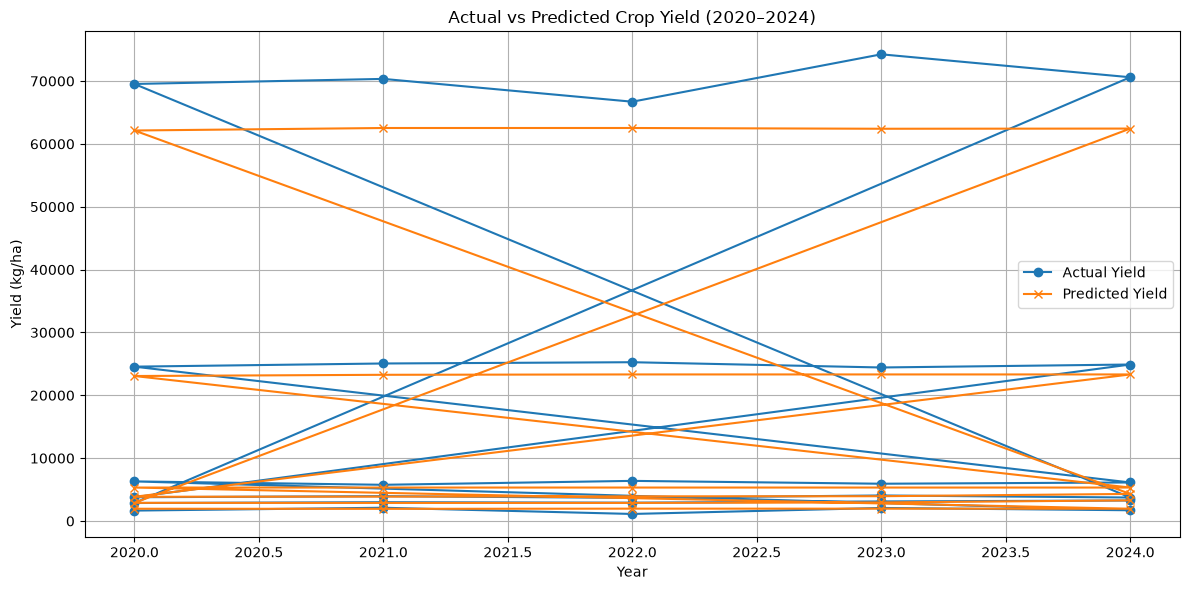

In [121]:
# ACTUAL vs PREDICTED YIELD — TEST SET

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    results_df["Year"],
    results_df["Actual_Yield"],
    marker="o",
    label="Actual Yield"
)

plt.plot(
    results_df["Year"],
    results_df["Predicted_Yield"],
    marker="x",
    label="Predicted Yield"
)

plt.title("Actual vs Predicted Crop Yield (2020–2024)")
plt.xlabel("Year")
plt.ylabel("Yield (kg/ha)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

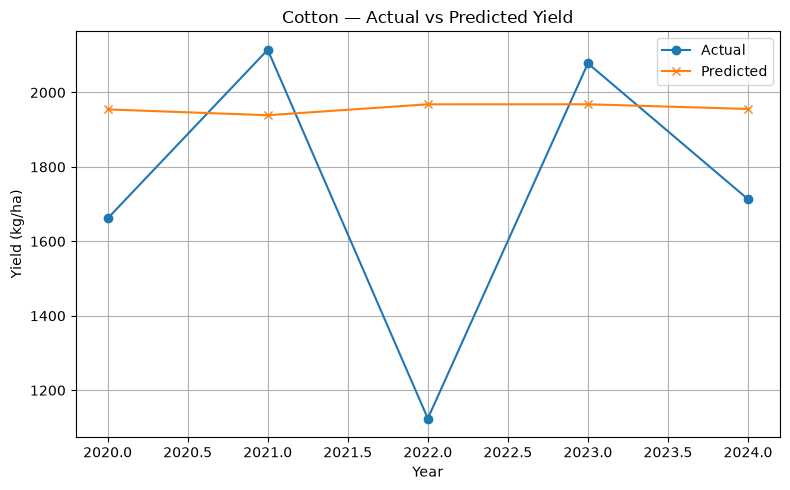

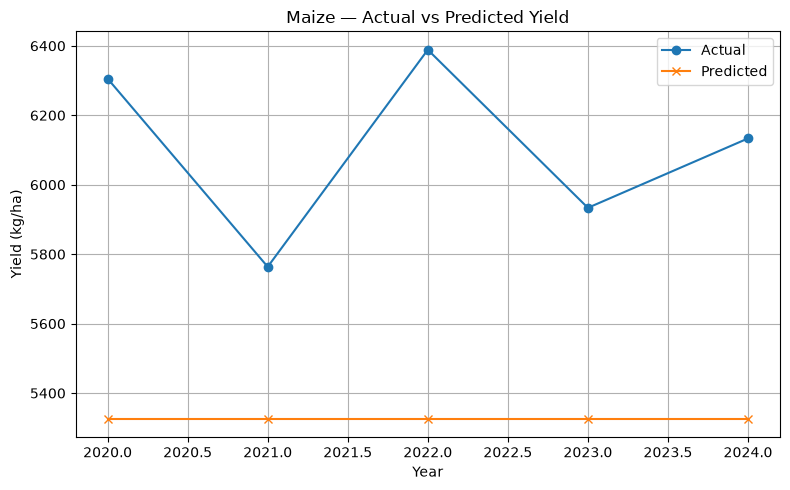

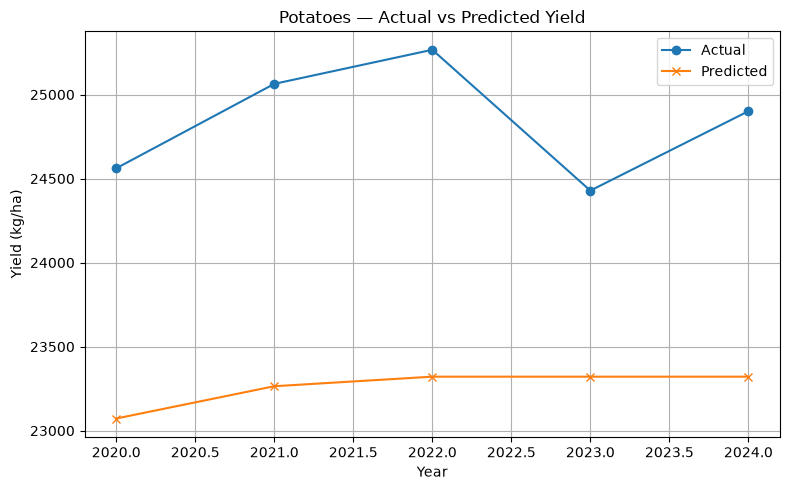

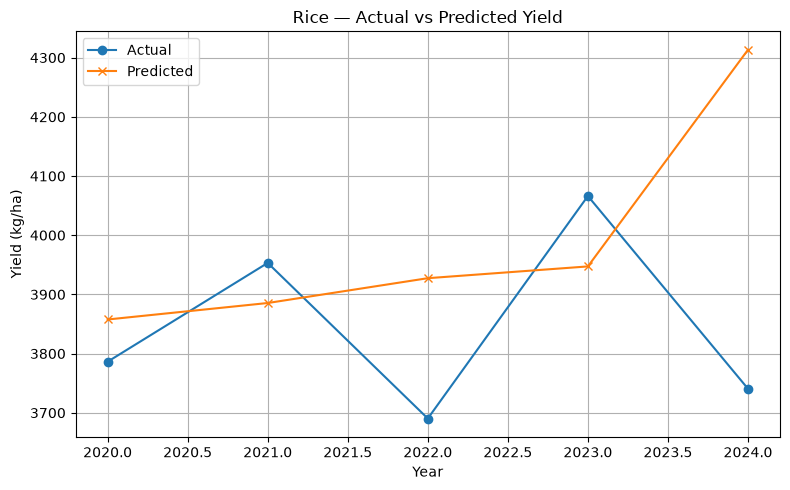

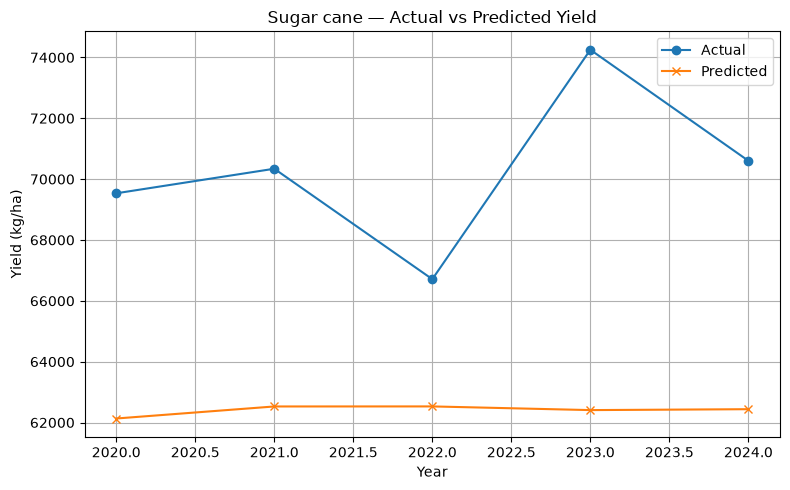

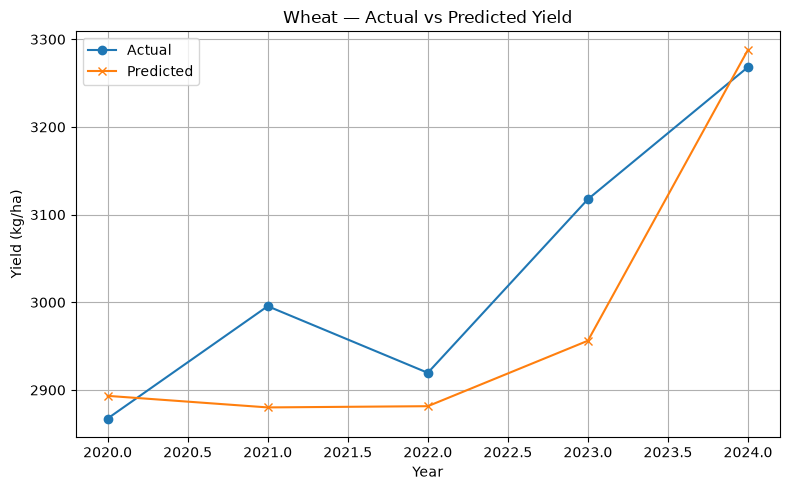

In [122]:
# CROP-WISE ACTUAL vs PREDICTED

crops = results_df["Crop"].unique()

for crop in crops:

    crop_data = results_df[
        results_df["Crop"] == crop
    ].sort_values("Year")

    plt.figure(figsize=(8, 5))

    plt.plot(
        crop_data["Year"],
        crop_data["Actual_Yield"],
        marker="o",
        label="Actual"
    )

    plt.plot(
        crop_data["Year"],
        crop_data["Predicted_Yield"],
        marker="x",
        label="Predicted"
    )

    plt.title(f"{crop} — Actual vs Predicted Yield")
    plt.xlabel("Year")
    plt.ylabel("Yield (kg/ha)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Final Gradient Boosting model save

In [123]:
import joblib
from pathlib import Path

# Create model folder
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

# Save final model
joblib.dump(final_model, model_dir / "crop_yield_gradient_boosting.pkl")

print("Model saved successfully!")

Model saved successfully!


# Save Encoder 

In [124]:
joblib.dump(
    encoder,
    model_dir / "crop_encoder.pkl"
)

print("Encoder saved successfully!")

Encoder saved successfully!


# Save Feature names

In [125]:
feature_names = (
    numeric_cols +
    list(encoder.get_feature_names_out(["Crop"]))
)

joblib.dump(
    feature_names,
    model_dir / "feature_names.pkl"
)

print("Feature names saved successfully!")
print(feature_names)

Feature names saved successfully!
['Year', 'Area_Harvested_ha', 'Production_tonnes', 'Previous_Yield', 'Previous_Area', 'Previous_Production', 'Yield_Lag_2', 'Yield_Lag_3', 'Yield_Rolling_3', 'Crop_Cotton', 'Crop_Maize', 'Crop_Potatoes', 'Crop_Rice', 'Crop_Sugar cane', 'Crop_Wheat']


# Save 2025 predictions CSV

In [126]:
forecast_results.to_csv(
    "2025_crop_yield_forecast.csv",
    index=False
)

print("2025 forecast saved successfully!")

2025 forecast saved successfully!


In [127]:
print("Saved files:")

for file in model_dir.iterdir():
    print(file)

print("\n2025 forecast file:")
print(Path("2025_crop_yield_forecast.csv").exists())

Saved files:
models\crop_encoder.pkl
models\crop_yield_gradient_boosting.pkl
models\feature_names.pkl

2025 forecast file:
True


In [128]:
import joblib

loaded_model = joblib.load(
    "models/crop_yield_gradient_boosting.pkl"
)

loaded_encoder = joblib.load(
    "models/crop_encoder.pkl"
)

loaded_features = joblib.load(
    "models/feature_names.pkl"
)

print("Model loaded successfully!")
print("Encoder loaded successfully!")
print("Features:")
print(loaded_features)

Model loaded successfully!
Encoder loaded successfully!
Features:
['Year', 'Area_Harvested_ha', 'Production_tonnes', 'Previous_Yield', 'Previous_Area', 'Previous_Production', 'Yield_Lag_2', 'Yield_Lag_3', 'Yield_Rolling_3', 'Crop_Cotton', 'Crop_Maize', 'Crop_Potatoes', 'Crop_Rice', 'Crop_Sugar cane', 'Crop_Wheat']


In [129]:
# SAVE MODEL EVALUATION RESULTS FOR STREAMLIT


from pathlib import Path

BASE_DIR = Path.cwd()

# ------------------------------------------------------------
# 1. Save test predictions
# ------------------------------------------------------------

test_predictions = results_df[
    [
        "Crop",
        "Year",
        "Actual_Yield",
        "Predicted_Yield",
        "Error"
    ]
].copy()

test_predictions.to_csv(
    BASE_DIR / "test_predictions.csv",
    index=False
)

print("✅ test_predictions.csv saved")
print(test_predictions.shape)


# ------------------------------------------------------------
# 2. Save crop-wise performance
# ------------------------------------------------------------

performance_export = crop_performance.reset_index()

# Make sure crop column exists
if "Crop" not in performance_export.columns:
    performance_export = performance_export.rename(
        columns={"index": "Crop"}
    )

performance_export.to_csv(
    BASE_DIR / "crop_performance.csv",
    index=False
)

print("✅ crop_performance.csv saved")
print(performance_export)

✅ test_predictions.csv saved
(30, 5)
✅ crop_performance.csv saved
         Crop      MAE     RMSE     R2
0      Cotton   349.88   450.15  -0.58
1       Maize   787.23   820.44 -11.59
2    Potatoes  1109.06  1165.44 -13.07
3        Rice   326.88   379.70  -6.29
4  Sugar cane  7860.73  8230.57 -10.61
5       Wheat   151.31   184.27  -0.63


In [130]:
print(Path("test_predictions.csv").exists())
print(Path("crop_performance.csv").exists())

True
True
